In [203]:
%pip install tensorflow==2.20.0 scikit-learn seaborn matplotlib pandas numpy sastrawi nltk

Note: you may need to restart the kernel to use updated packages.


In [204]:
# ============================================================
# 1) Setup environment dan import library
# ============================================================
import os
import re
import json
import random
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    )
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, ComplementNB
from sklearn.utils.class_weight import compute_class_weight

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path('content/reviews_hok_newest.csv')
SLANG_PATH = Path('slangwords_hok.json')

print(f'DATA_PATH exists: {DATA_PATH.exists()}')
print(f'SLANG_PATH exists: {SLANG_PATH.exists()}')

DATA_PATH exists: True
SLANG_PATH exists: True


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [205]:
df_raw = pd.read_csv('reviews_hok.csv')
print('Raw shape:', df_raw.shape)
display(df_raw.head())

Raw shape: (10000, 6)


,review_id,user_name,score,content,thumbs_up,app_version
0,2c793cc6-a533-4756-899c-929fe0905f1f,Muhammad Ramadani,5,"game nya seru, developer nya baik, heronya bal...",11,11.3.1.8
1,03d587fa-daa9-4a40-b7c0-31ad6207ec45,Andriyanto,2,tolong perbaiki peforma peningkatan sinyal nya...,2,11.3.1.9
2,f9f2926a-cfd2-4c77-b668-48813c845d28,Andika,2,gamenya udah bagus cuma ada kekurangan di fitu...,1,11.3.1.9
3,6febf65b-1bcd-4893-879a-03b7679ea16c,icooo,1,"game rusak game rusak, lain kali kalo update j...",0,11.3.1.9
4,7a0f84f8-5c43-497a-b6c2-35b045d29061,Nur Juminati,5,"Suka banget sama game nya, soalnya hero nya ju...",1,11.3.1.9


In [206]:
df = df_raw[['content', 'score']].copy()
df.columns = ['text', 'score']

# Pastikan score numerik
df['score'] = pd.to_numeric(df['score'], errors='coerce')

print('Data setelah seleksi kolom:', df.shape)
display(df.head())

Data setelah seleksi kolom: (10000, 2)


,text,score
0,"game nya seru, developer nya baik, heronya bal...",5
1,tolong perbaiki peforma peningkatan sinyal nya...,2
2,gamenya udah bagus cuma ada kekurangan di fitu...,2
3,"game rusak game rusak, lain kali kalo update j...",1
4,"Suka banget sama game nya, soalnya hero nya ju...",5


In [207]:
df_balanced = df_balanced = (
    df.groupby('score', group_keys=False)
      .sample(n=200, replace=False, random_state=42)
      .reset_index(drop=True)
)
df_balanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    1000 non-null   str  
 1   score   1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 15.8 KB


Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    1000 non-null   str  
 1   score   1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 15.8 KB


None


Missing values:


,missing_count
text,0
score,0



Duplicate rows: 0

Distribusi score (count):


,count
score,
1,200
2,200
3,200
4,200
5,200



Distribusi score (persentase):


,pct
score,
1,20.0
2,20.0
3,20.0
4,20.0
5,20.0


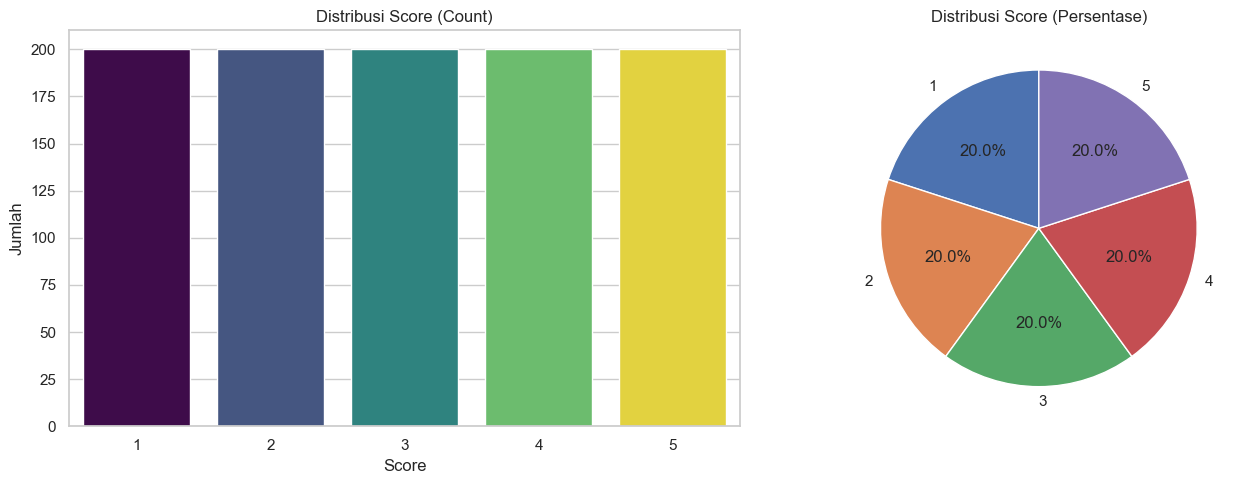

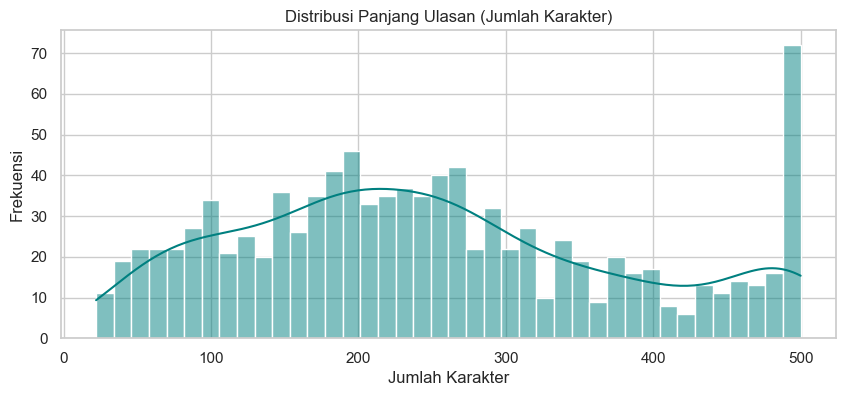

In [208]:
print('Info dataset:')
display(df_balanced.info())

print('\nMissing values:')
display(df_balanced.isna().sum().to_frame('missing_count'))

print('\nDuplicate rows:', df_balanced.duplicated().sum())

print('\nDistribusi score (count):')
score_count = df_balanced['score'].value_counts(dropna=False).sort_index()
display(score_count.to_frame('count'))

print('\nDistribusi score (persentase):')
score_pct = (df_balanced['score'].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
display(score_pct.to_frame('pct'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
  data=df_balanced, 
  x='score', 
  order=sorted(df_balanced['score'].dropna().unique()), 
  ax=axes[0], 
  palette='viridis',
  hue='score',
  legend=False,
)
axes[0].set_title('Distribusi Score (Count)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Jumlah')

axes[1].pie(
  score_count.values, 
  labels=[str(x) for x in score_count.index], 
  autopct='%1.1f%%', 
  startangle=90,
)
axes[1].set_title('Distribusi Score (Persentase)')

plt.tight_layout()
plt.show()

# Distribusi panjang karakter content
df_balanced['char_len'] = df_balanced['text'].astype(str).str.len()

plt.figure(figsize=(10, 4))
sns.histplot(df_balanced['char_len'], bins=40, kde=True, color='teal')
plt.title('Distribusi Panjang Ulasan (Jumlah Karakter)')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

In [209]:
df_balanced = df_balanced.drop_duplicates()
display(df_balanced.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   text      1000 non-null   str  
 1   score     1000 non-null   int64
 2   char_len  1000 non-null   int64
dtypes: int64(2), str(1)
memory usage: 23.6 KB


None

In [210]:
url_re = re.compile(r'https?://\S+|www\.\S+')
mention_re = re.compile(r'@[A-Za-z0-9_]+')
hashtag_re = re.compile(r'#[A-Za-z0-9_]+')
non_letter_re = re.compile(r'[^a-zA-Z\s]')
multispace_re = re.compile(r'\s+')

def cleaning_and_casfolding_text(text: str) -> str:
    text = str(text)
    text = url_re.sub(' ', text)
    text = mention_re.sub(' ', text)
    text = hashtag_re.sub(' ', text)
    text = text.replace('RT', ' ')
    text = non_letter_re.sub(' ', text)
    text = multispace_re.sub(' ', text).strip()
    return str(text).lower().strip()
  
df_balanced['clean_text'] = df_balanced['text'].apply(cleaning_and_casfolding_text)
df_balanced[['text', 'clean_text']].head()

,text,clean_text
0,Dear tim HOK saya sering mengalami stuck pada ...,dear tim hok saya sering mengalami stuck pada ...
1,Ini tolong diperbaiki sistem match making nya ...,ini tolong diperbaiki sistem match making nya ...
2,"jujur, ini game 100% diseting siapa pemenangny...",jujur ini game diseting siapa pemenangnya saya...
3,"Game sialan, ngelag mulu rekan game kebanyak b...",game sialan ngelag mulu rekan game kebanyak bo...
4,"Tolong lag perbaiki lagi pembagian pemain nya,...",tolong lag perbaiki lagi pembagian pemain nya ...


In [211]:
with open(SLANG_PATH, 'r', encoding='utf-8') as f:
    slangwords = json.load(f)

def fix_slangwords(text: str) -> str:
    normalized = [slangwords.get(slang, slang) for slang in str(text).split()]
    return ' '.join(normalized)

# Simpan teks hasil normalisasi slang untuk proses labeling lexicon
df_balanced['clean_text'] = df_balanced['clean_text'].apply(fix_slangwords)
df_balanced['lexicon_text'] = df_balanced['clean_text']
df_balanced[['text', 'clean_text', 'lexicon_text']].head()

,text,clean_text,lexicon_text
0,Dear tim HOK saya sering mengalami stuck pada ...,dear tim hok saya sering mengalami stuck pada ...,dear tim hok saya sering mengalami stuck pada ...
1,Ini tolong diperbaiki sistem match making nya ...,ini tolong diperbaiki sistem match making nya ...,ini tolong diperbaiki sistem match making nya ...
2,"jujur, ini game 100% diseting siapa pemenangny...",jujur ini game diseting siapa pemenangnya saya...,jujur ini game diseting siapa pemenangnya saya...
3,"Game sialan, ngelag mulu rekan game kebanyak b...",game sialan lag mulu rekan game kebanyak bot s...,game sialan lag mulu rekan game kebanyak bot s...
4,"Tolong lag perbaiki lagi pembagian pemain nya,...",tolong lag perbaiki lagi pembagian pemain nya ...,tolong lag perbaiki lagi pembagian pemain nya ...


In [213]:
df_balanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   text          1000 non-null   str  
 1   score         1000 non-null   int64
 2   char_len      1000 non-null   int64
 3   clean_text    1000 non-null   str  
 4   lexicon_text  1000 non-null   str  
dtypes: int64(2), str(3)
memory usage: 39.2 KB


In [212]:
factory = StopWordRemoverFactory()
stopwords_sastrawi = set(factory.get_stop_words())  # pakai set agar lookup O(1)
stemmer = StemmerFactory().create_stemmer()

stem_cache = {}
def fast_stem(word: str) -> str:
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)
    return stem_cache[word]

def filtering_text(text: str) -> str:
    tokens = str(text).split()  # lebih ringan dari word_tokenize
    tokens = [w for w in tokens if w not in stopwords_sastrawi]
    stems = [fast_stem(w) for w in tokens]
    return " ".join(stems)

# clean_text khusus fitur model (setelah stemming)
df_balanced["clean_text"] = df_balanced["clean_text"].apply(filtering_text)

KeyboardInterrupt: 

In [ ]:
positives = {
    'baik','seru','suka','bagus','puas','lucu','fair','murah','keren','mantap',
    'gratis','rapi','oke','ok','senang','cepat','adil','menarik','asik','epic',
    'halus','stabil','ringan','ramah','mantul','top','hebat','rekomendasi',
    'worth','fun','balance','seimbang','responsif'
}

negatives = {
    'lag','lambat','buruk','freeze','crash','kecewa','afk','toxic','sampah',
    'error','jelek','hang','stres','dark','feed','noob','bodoh','mahal','stuck',
    'parah','payah','rusak','lemot','ngelag','patah','delay','disconnect','dc',
    'forceclose','boros','curang','unfair','aneh','gagal','berat'
}

# Kata penguat (intensifier), penyangkal (negator), dan kontras
intensifier = {'sangat', 'banget', 'amat', 'terlalu'}
negator = {'tidak', 'bukan', 'ga', 'gak'}
contrast = {'tapi', 'namun', 'cuma', 'walau', 'meski'}

def lexicon_score(tokens_str: str) -> int:
    score = 0
    prev = ''
    after_contrast = False

    for t in str(tokens_str).split():
        if t in contrast:
            after_contrast = True
            prev = t
            continue

        s = 1 if t in positives else (-1 if t in negatives else 0)

        if prev in negator and s != 0:
            s = -s
        if prev in intensifier and s != 0:
            s *= 2

        # Setelah kata kontras, opini biasanya lebih menentukan
        if after_contrast and s != 0:
            s *= 2

        score += s
        prev = t

    return score

def label_from_text(tokens_str: str) -> str:
    s = lexicon_score(tokens_str)
    if s > 0:
        return 'positive'
    if s < 0:
        return 'negative'
    return 'neutral'

# Label diambil dari lexicon_text (sebelum stemming) agar match kosakata lebih baik
df_balanced['sentiment'] = df_balanced['lexicon_text'].apply(label_from_text)

print(df_balanced['sentiment'].value_counts())
df_balanced[['text', 'lexicon_text', 'clean_text', 'sentiment']].head()

sentiment
positive    970
negative    669
neutral     611
Name: count, dtype: int64


,text,lexicon_text,clean_text,sentiment
0,Dear tim HOK saya sering mengalami stuck pada ...,dear tim hok saya sering mengalami stuck pada ...,dear tim hok sering alami stuck loading match ...,negative
1,Ini tolong diperbaiki sistem match making nya ...,ini tolong diperbaiki sistem match making nya ...,baik sistem match making nya kok grandmaster b...,negative
2,"jujur, ini game 100% diseting siapa pemenangny...",jujur ini game diseting siapa pemenangnya saya...,jujur game ting siapa menang main bulan ranked...,neutral
3,"Game sialan, ngelag mulu rekan game kebanyak b...",game sialan lag mulu rekan game kebanyak bot s...,game sial lag mulu rekan game banyak bot syste...,negative
4,"Tolong lag perbaiki lagi pembagian pemain nya,...",tolong lag perbaiki lagi pembagian pemain nya ...,lag baik bagi main nya trus main afk orang bag...,negative


Distribusi label sentiment:


,count
sentiment,
positive,970
negative,669
neutral,611


,pct
sentiment,
positive,43.11
negative,29.73
neutral,27.16


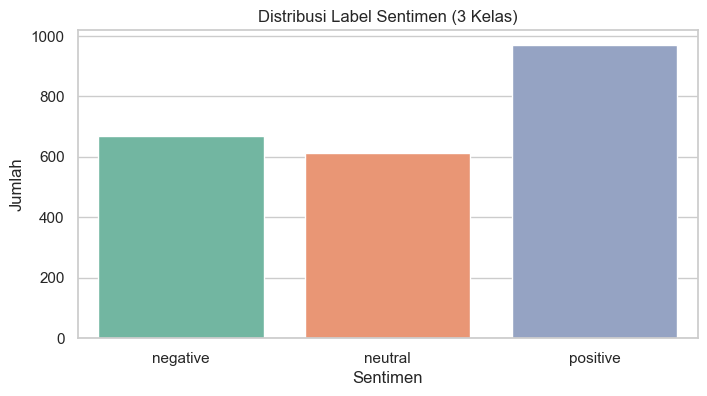

In [ ]:
print('Distribusi label sentiment:')
display(df_balanced['sentiment'].value_counts().to_frame('count'))

display(
    (df_balanced['sentiment'].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame('pct')
)

plt.figure(figsize=(8, 4))
sns.countplot(data=df_balanced, x='sentiment', order=['negative', 'neutral', 'positive'], palette='Set2', hue="sentiment")
plt.title('Distribusi Label Sentimen (3 Kelas)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

In [ ]:
X = df_balanced['clean_text']
y = df_balanced['sentiment']

# Bagi data 80% untuk training, 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data latih :", len(X_train))
print("Data uji   :", len(X_test))

Data latih : 1800
Data uji   : 450


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Konfigurasi awal yang biasanya lebih kuat untuk teks sentimen
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    norm='l2',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print("Shape TF-IDF:")
print("Train:", X_train_tfidf.shape)
print("Test :", X_test_tfidf.shape)

Shape TF-IDF:
Train: (1800, 4025)
Test : (450, 4025)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=SEED,
    ),
    "SVM": LinearSVC(
        class_weight='balanced',
        random_state=SEED,
    ),
    "Complement Naive Bayes": ComplementNB(alpha=1.0),
}


=== Logistic Regression ===
Accuracy         : 70.67%
Macro F1         : 69.29%
Weighted F1      : 70.73%
Balanced Accuracy: 69.29%
              precision    recall  f1-score   support

    negative     0.7143    0.6343    0.6719       134
     neutral     0.5882    0.6557    0.6202       122
    positive     0.7846    0.7887    0.7866       194

    accuracy                         0.7067       450
   macro avg     0.6957    0.6929    0.6929       450
weighted avg     0.7104    0.7067    0.7073       450


=== SVM ===
Accuracy         : 69.33%
Macro F1         : 67.37%
Weighted F1      : 69.01%
Balanced Accuracy: 67.09%
              precision    recall  f1-score   support

    negative     0.6917    0.6194    0.6535       134
     neutral     0.6034    0.5738    0.5882       122
    positive     0.7430    0.8196    0.7794       194

    accuracy                         0.6933       450
   macro avg     0.6794    0.6709    0.6737       450
weighted avg     0.6899    0.6933    0.6901

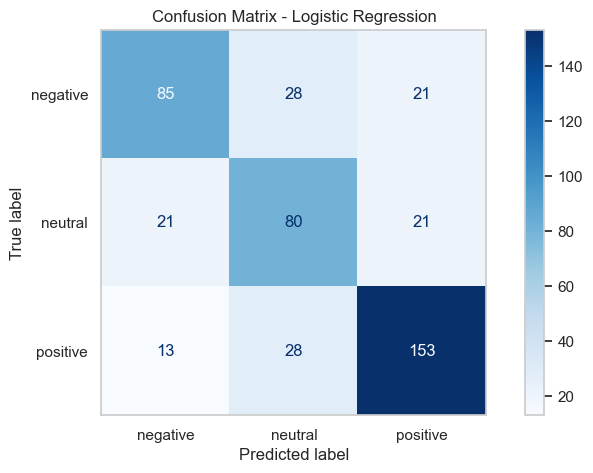

In [ ]:
results = {}
predictions_cache = {}

# Latih dan uji tiap model
for name, m in models.items():
    m.fit(X_train_tfidf, y_train)
    pred = m.predict(X_test_tfidf)
    predictions_cache[name] = pred

    acc = accuracy_score(y_test, pred)
    f1_macro = f1_score(y_test, pred, average='macro')
    f1_weighted = f1_score(y_test, pred, average='weighted')
    bal_acc = balanced_accuracy_score(y_test, pred)

    results[name] = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'balanced_accuracy': bal_acc,
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy         : {acc*100:.2f}%")
    print(f"Macro F1         : {f1_macro*100:.2f}%")
    print(f"Weighted F1      : {f1_weighted*100:.2f}%")
    print(f"Balanced Accuracy: {bal_acc*100:.2f}%")
    print(classification_report(y_test, pred, digits=4))

# Pilih model terbaik berdasarkan Macro F1
best_model_name = max(results, key=lambda k: results[k]['f1_macro'])
best_model = models[best_model_name]
best_pred = predictions_cache[best_model_name]

print("\nModel terbaik (berdasarkan Macro F1):")
print(
    f"{best_model_name} | "
    f"Acc={results[best_model_name]['accuracy']*100:.2f}% | "
    f"MacroF1={results[best_model_name]['f1_macro']*100:.2f}%"
)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=['negative', 'neutral', 'positive'],
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['negative', 'neutral', 'positive'],
)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.grid(False)
plt.show()

In [ ]:
# Inference: prediksi sentimen untuk teks baru
def preprocess_for_inference(text: str) -> str:
    x = cleaning_and_casfolding_text(text)
    x = fix_slangwords(x)
    x = filtering_text(x)
    return x

def predict_sentiment(text: str) -> dict:
    cleaned = preprocess_for_inference(text)
    features = vectorizer.transform([cleaned])
    pred = best_model.predict(features)[0]
    return {
        'text': text,
        'clean_text': cleaned,
        'sentiment': pred,
    }

# Contoh inference
samples = [
    'Game ini seru banget, grafik bagus dan adil',
    'Parah lag terus, sering crash, sangat mengecewakan',
    'Lumayan, kadang bagus kadang biasa saja',
]

for s in samples:
    out = predict_sentiment(s)
    print(f"Text      : {out['text']}")
    print(f"Clean text: {out['clean_text']}")
    print(f"Prediksi  : {out['sentiment']}")
    print('-' * 80)

# Contoh pakai satu teks manual:
# predict_sentiment('isi ulasan kamu di sini')

Text      : Game ini seru banget, grafik bagus dan adil
Clean text: game seru sangat grafik bagus adil
Prediksi  : positive
--------------------------------------------------------------------------------
Text      : Parah lag terus, sering crash, sangat mengecewakan
Clean text: parah lag terus sering crash sangat kecewa
Prediksi  : negative
--------------------------------------------------------------------------------
Text      : Lumayan, kadang bagus kadang biasa saja
Clean text: lumayan kadang bagus kadang biasa
Prediksi  : positive
--------------------------------------------------------------------------------


In [ ]:
# Buat daftar library yang dipakai
!pip freeze > requirements.txt
print("File 'requirements.txt' berhasil dibuat.")

File 'requirements.txt' berhasil dibuat.
